In [1]:
import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt

print("MediaPipe version:", mp.__version__)
print("OpenCV version:", cv2.__version__)

MediaPipe version: 1.0.1
OpenCV version: 4.10.0


Face detected! Landmarks found: 478


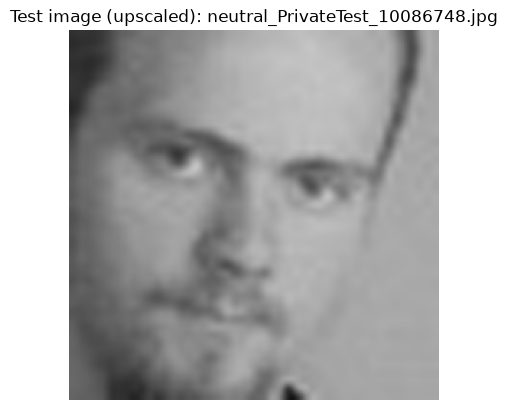

In [ ]:
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision

base_options = mp_python.BaseOptions(model_asset_path='../models/face_landmarker.task')
options = mp_vision.FaceLandmarkerOptions(
    base_options=base_options,
    running_mode=mp_vision.RunningMode.IMAGE,
    num_faces=1,
    min_face_detection_confidence=0.5
)
detector = mp_vision.FaceLandmarker.create_from_options(options)


import os
test_class_dir = "../dataset/clean/test/neutral"
test_image_name = os.listdir(test_class_dir)[0]
test_image_path = os.path.join(test_class_dir, test_image_name)

image_bgr = cv2.imread(test_image_path)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


image_resized = cv2.resize(image_rgb, (256, 256), interpolation=cv2.INTER_CUBIC)

mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_resized)
detection_result = detector.detect(mp_image)

if detection_result.face_landmarks:
    print(f"Face detected! Landmarks found: {len(detection_result.face_landmarks[0])}")
else:
    print("No face detected in this image.")

plt.imshow(image_resized)
plt.axis('off')
plt.title(f"Test image (upscaled): {test_image_name}")
plt.show()

In [5]:
def calculate_ear(landmarks, eye_indices, image_width, image_height):
    points = []
    for idx in eye_indices:
        lm = landmarks[idx]
        points.append((lm.x * image_width, lm.y * image_height))

    points = np.array(points)

    vertical_1 = np.linalg.norm(points[1] - points[5])
    vertical_2 = np.linalg.norm(points[2] - points[4])
    horizontal = np.linalg.norm(points[0] - points[3])

    ear = (vertical_1 + vertical_2) / (2.0 * horizontal)
    return ear

RIGHT_EYE = [33, 160, 158, 133, 153, 144]
LEFT_EYE = [362, 385, 387, 263, 373, 380]

face_landmarks = detection_result.face_landmarks[0]
img_h, img_w = image_resized.shape[:2]

right_ear = calculate_ear(face_landmarks, RIGHT_EYE, img_w, img_h)
left_ear = calculate_ear(face_landmarks, LEFT_EYE, img_w, img_h)
avg_ear = (right_ear + left_ear) / 2.0

print(f"Right Eye EAR: {right_ear:.4f}")
print(f"Left Eye EAR:  {left_ear:.4f}")
print(f"Average EAR:   {avg_ear:.4f}")

Right Eye EAR: 0.3375
Left Eye EAR:  0.3800
Average EAR:   0.3588


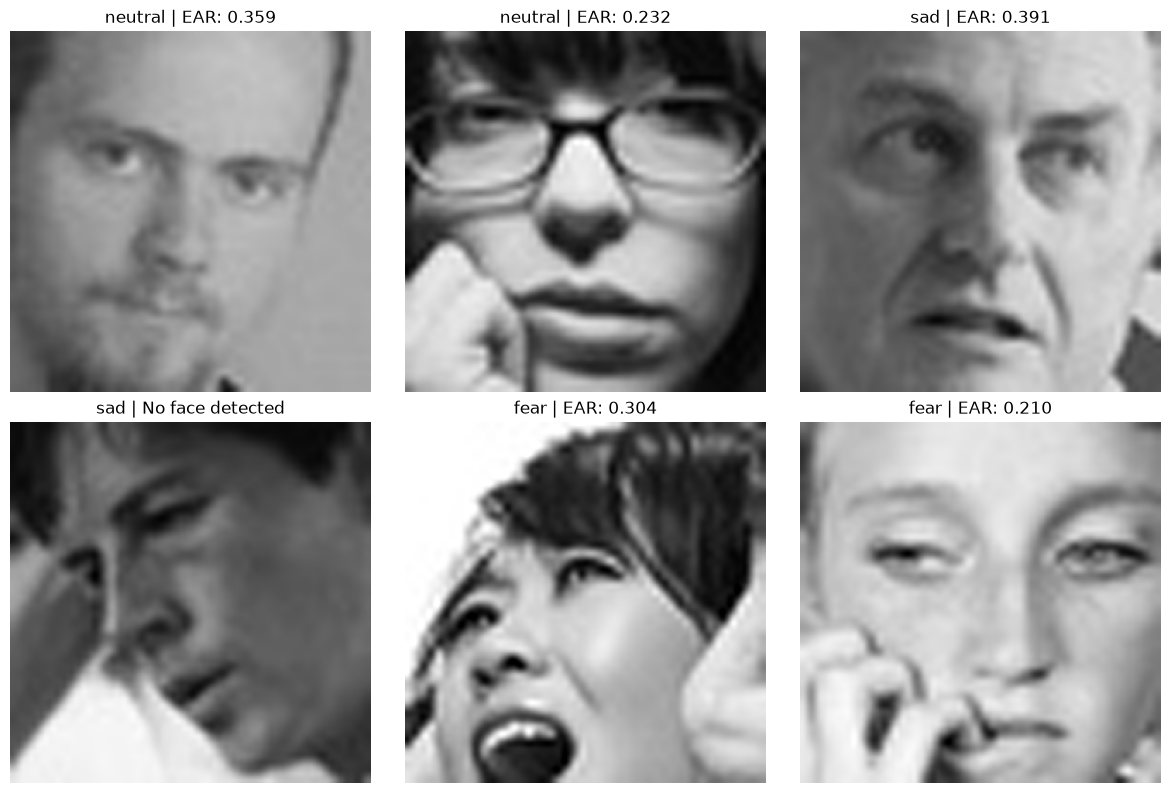

In [6]:
def get_ear_for_image(image_path, detector):
    image_bgr = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    image_resized = cv2.resize(image_rgb, (256, 256), interpolation=cv2.INTER_CUBIC)

    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_resized)
    result = detector.detect(mp_image)

    if not result.face_landmarks:
        return None, image_resized

    face_landmarks = result.face_landmarks[0]
    img_h, img_w = image_resized.shape[:2]

    right_ear = calculate_ear(face_landmarks, RIGHT_EYE, img_w, img_h)
    left_ear = calculate_ear(face_landmarks, LEFT_EYE, img_w, img_h)
    avg_ear = (right_ear + left_ear) / 2.0

    return avg_ear, image_resized

# Test images ගණනක් ගන්නවා, class ගණනක් අරගෙන
test_samples = [
    ("../dataset/clean/test/neutral", 0),
    ("../dataset/clean/test/neutral", 5),
    ("../dataset/clean/test/sad", 0),
    ("../dataset/clean/test/sad", 5),
    ("../dataset/clean/test/fear", 0),
    ("../dataset/clean/test/fear", 5),
]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, (class_dir, img_idx) in enumerate(test_samples):
    img_name = sorted(os.listdir(class_dir))[img_idx]
    img_path = os.path.join(class_dir, img_name)

    ear, img_display = get_ear_for_image(img_path, detector)

    class_name = class_dir.split('/')[-1]
    axes[i].imshow(img_display)
    axes[i].axis('off')

    if ear is not None:
        axes[i].set_title(f"{class_name} | EAR: {ear:.3f}")
    else:
        axes[i].set_title(f"{class_name} | No face detected")

plt.tight_layout()
plt.savefig('../outputs/figures/07_ear_comparison.png', dpi=150)
plt.show()

In [7]:
EAR_THRESHOLD = 0.20
CONSECUTIVE_FRAMES_REQUIRED = 3

class SleepyDetector:
    def __init__(self, ear_threshold=0.20, consecutive_frames=3):
        self.ear_threshold = ear_threshold
        self.consecutive_frames = consecutive_frames
        self.low_ear_counter = 0

    def update(self, avg_ear):
        if avg_ear is None:
            
            return False

        if avg_ear < self.ear_threshold:
            self.low_ear_counter += 1
        else:
            self.low_ear_counter = 0

        is_sleepy = self.low_ear_counter >= self.consecutive_frames
        return is_sleepy


simulated_ear_stream = [0.35, 0.33, 0.18, 0.17, 0.16, 0.34, 0.19, 0.15, 0.14, 0.13]

detector_sleepy = SleepyDetector(ear_threshold=EAR_THRESHOLD, consecutive_frames=CONSECUTIVE_FRAMES_REQUIRED)

for i, ear_value in enumerate(simulated_ear_stream):
    sleepy_flag = detector_sleepy.update(ear_value)
    print(f"Frame {i+1}: EAR={ear_value:.2f} | Low-EAR streak={detector_sleepy.low_ear_counter} | Sleepy Alert: {sleepy_flag}")

Frame 1: EAR=0.35 | Low-EAR streak=0 | Sleepy Alert: False
Frame 2: EAR=0.33 | Low-EAR streak=0 | Sleepy Alert: False
Frame 3: EAR=0.18 | Low-EAR streak=1 | Sleepy Alert: False
Frame 4: EAR=0.17 | Low-EAR streak=2 | Sleepy Alert: False
Frame 5: EAR=0.16 | Low-EAR streak=3 | Sleepy Alert: True
Frame 6: EAR=0.34 | Low-EAR streak=0 | Sleepy Alert: False
Frame 7: EAR=0.19 | Low-EAR streak=1 | Sleepy Alert: False
Frame 8: EAR=0.15 | Low-EAR streak=2 | Sleepy Alert: False
Frame 9: EAR=0.14 | Low-EAR streak=3 | Sleepy Alert: True
Frame 10: EAR=0.13 | Low-EAR streak=4 | Sleepy Alert: True
